# LUNA16 Detector Batch - Normauto

Visualizza esattamente la batch che arriva al detector SCPMNet con `intensity_mode='auto'` e cache dei volumi normalizzati.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.patches import Circle
from torch.utils.data import DataLoader

PROJECT_DIR = Path.cwd()
while PROJECT_DIR != PROJECT_DIR.parent and not (PROJECT_DIR / 'src').exists():
    PROJECT_DIR = PROJECT_DIR.parent
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.det.SCPMNet.dataset import SCPMCSVVolumeDataset, scpm_collate

print('PROJECT_DIR =', PROJECT_DIR)

PROJECT_DIR = /Users/domenicopaolo/Documents/works/lung_ct_3d2d_synthesis


In [2]:
# Parametri allineati allo script server: run_luna16_detector_normauto_a100.sh
DATA_ROOT = Path('/ssd2/domenico/datasets/LUNA16_preprocessed')
SPLIT_DIR = DATA_ROOT / 'cv_splits'
FOLD = 0
SPLIT = 'train'
CSV_PATH = SPLIT_DIR / f'luna16_fold{FOLD}.csv'

BATCH_SIZE = 8
NUM_WORKERS = 0
CROP_SIZE = (96, 96, 96)
INTENSITY_MODE = 'auto'
NORMALIZED_VOLUME_CACHE_DIR = Path('outputs/scpmnet_luna16_10fold_fpr_top100_focal_balanced_average_normauto/normalized_volume_cache_auto')

# Fallback utile quando il notebook viene aperto sul Mac.
if not DATA_ROOT.exists():
    DATA_ROOT = Path('/Users/domenicopaolo/Documents/datasets/LUNA16/LUNA16_preprocessed')
    SPLIT_DIR = DATA_ROOT / 'cv_splits'
    CSV_PATH = SPLIT_DIR / f'luna16_fold{FOLD}.csv'
    NORMALIZED_VOLUME_CACHE_DIR = Path('/Users/domenicopaolo/Documents/works/lung_ct_3d2d_synthesis/outputs/scpmnet_luna16_10fold_fpr_top100_focal_balanced_average_normauto/normalized_volume_cache_auto')

print('CSV_PATH =', CSV_PATH)
print('DATA_ROOT =', DATA_ROOT)
print('CACHE =', NORMALIZED_VOLUME_CACHE_DIR)
print('csv exists:', CSV_PATH.exists())
print('data root exists:', DATA_ROOT.exists())

CSV_PATH = /Users/domenicopaolo/Documents/datasets/LUNA16/LUNA16_preprocessed/cv_splits/luna16_fold0.csv
DATA_ROOT = /Users/domenicopaolo/Documents/datasets/LUNA16/LUNA16_preprocessed
CACHE = /Users/domenicopaolo/Documents/works/lung_ct_3d2d_synthesis/outputs/scpmnet_luna16_10fold_fpr_top100_focal_balanced_average_normauto/normalized_volume_cache_auto
csv exists: True
data root exists: True


In [3]:
ds = SCPMCSVVolumeDataset(
    csv_path=str(CSV_PATH),
    split=SPLIT,
    data_root=str(DATA_ROOT),
    crop_size=CROP_SIZE,
    samples_per_volume=1,
    clip=(-1000.0, 400.0),
    intensity_mode=INTENSITY_MODE,
    normalized_volume_cache_dir=str(NORMALIZED_VOLUME_CACHE_DIR),
    positive_crop_prob=0.7,
    deterministic_seed=233,
)
loader = DataLoader(
    ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=scpm_collate,
)
batch = next(iter(loader))

images = batch['image']
annots = batch['annot']
origins = batch['origin']
seriesuids = batch['seriesuid']

print('dataset len:', len(ds))
print('image batch:', tuple(images.shape), images.dtype)
print('annot batch:', tuple(annots.shape), annots.dtype)
print('origin batch:', tuple(origins.shape), origins.dtype)
print('image min/max/mean/std:', float(images.min()), float(images.max()), float(images.mean()), float(images.std()))
print('percentiles:', [round(float(v), 4) for v in torch.quantile(images.flatten(), torch.tensor([0.0, 0.01, 0.5, 0.99, 1.0])).tolist()])
print('seriesuids:', seriesuids[:min(3, len(seriesuids))])

dataset len: 710
image batch: (8, 1, 96, 96, 96) torch.float32
annot batch: (8, 1, 4) torch.float32
origin batch: (8, 3) torch.float32
image min/max/mean/std: -1.0 1.0 -0.5384109020233154 0.45816898345947266
percentiles: [-1.0, -1.0, -0.6471, 0.7412, 1.0]
seriesuids: ['1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860', '1.3.6.1.4.1.14519.5.2.1.6279.6001.100332161840553388986847034053', '1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793540579077826395208']


In [4]:
def valid_annots(annot_tensor):
    arr = annot_tensor.detach().cpu().numpy()
    return arr[arr[:, 3] > 0]

rows = []
for i, seriesuid in enumerate(seriesuids):
    anns = valid_annots(annots[i])
    x = images[i, 0]
    rows.append({
        'i': i,
        'seriesuid': seriesuid,
        'n_gt_in_crop': len(anns),
        'origin_zyx': [round(float(v), 1) for v in origins[i].tolist()],
        'min': round(float(x.min()), 4),
        'max': round(float(x.max()), 4),
        'mean': round(float(x.mean()), 4),
        'std': round(float(x.std()), 4),
    })
rows

[{'i': 0,
  'seriesuid': '1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860',
  'n_gt_in_crop': 1,
  'origin_zyx': [155.0, 23.0, 194.0],
  'min': -1.0,
  'max': 1.0,
  'mean': -0.572,
  'std': 0.4171},
 {'i': 1,
  'seriesuid': '1.3.6.1.4.1.14519.5.2.1.6279.6001.100332161840553388986847034053',
  'n_gt_in_crop': 0,
  'origin_zyx': [159.0, 68.0, 95.0],
  'min': -1.0,
  'max': 1.0,
  'mean': -0.505,
  'std': 0.5127},
 {'i': 2,
  'seriesuid': '1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793540579077826395208',
  'n_gt_in_crop': 0,
  'origin_zyx': [17.0, 21.0, 12.0],
  'min': -1.0,
  'max': 1.0,
  'mean': -0.7753,
  'std': 0.4437},
 {'i': 3,
  'seriesuid': '1.3.6.1.4.1.14519.5.2.1.6279.6001.100530488926682752765845212286',
  'n_gt_in_crop': 0,
  'origin_zyx': [129.0, 34.0, 182.0],
  'min': -1.0,
  'max': 1.0,
  'mean': -0.5076,
  'std': 0.4237},
 {'i': 4,
  'seriesuid': '1.3.6.1.4.1.14519.5.2.1.6279.6001.100620385482151095585000946543',
  'n_gt_in_crop': 0,
  'origin_zyx': [63

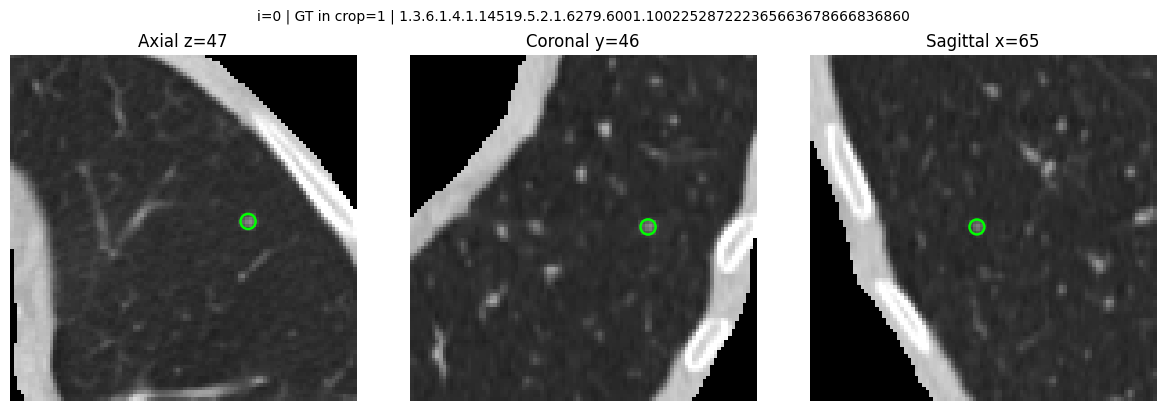

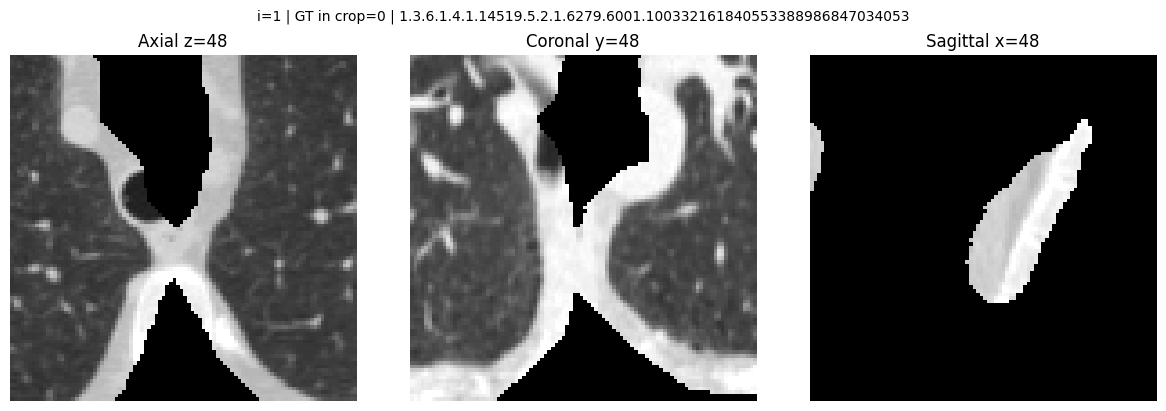

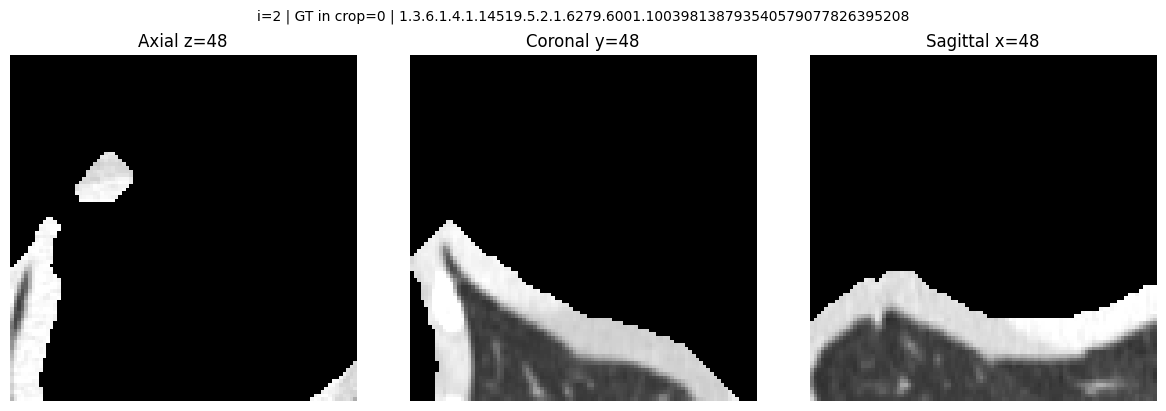

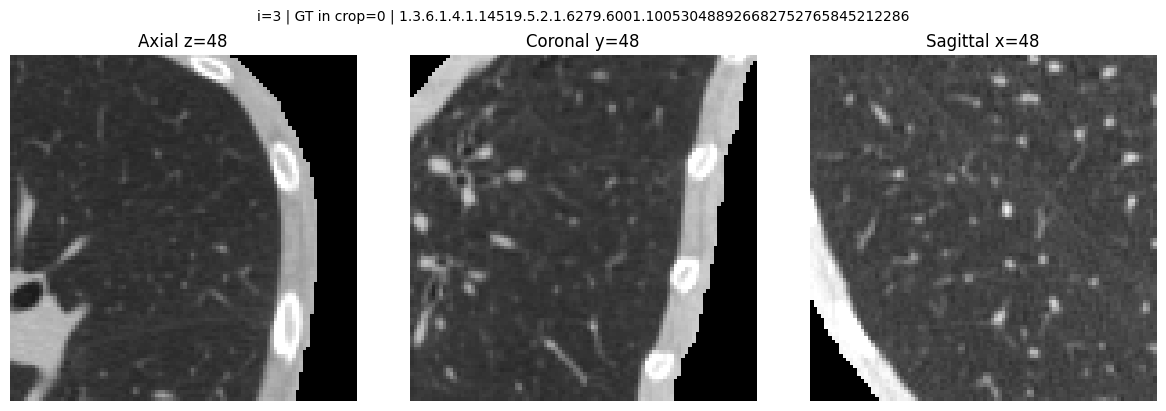

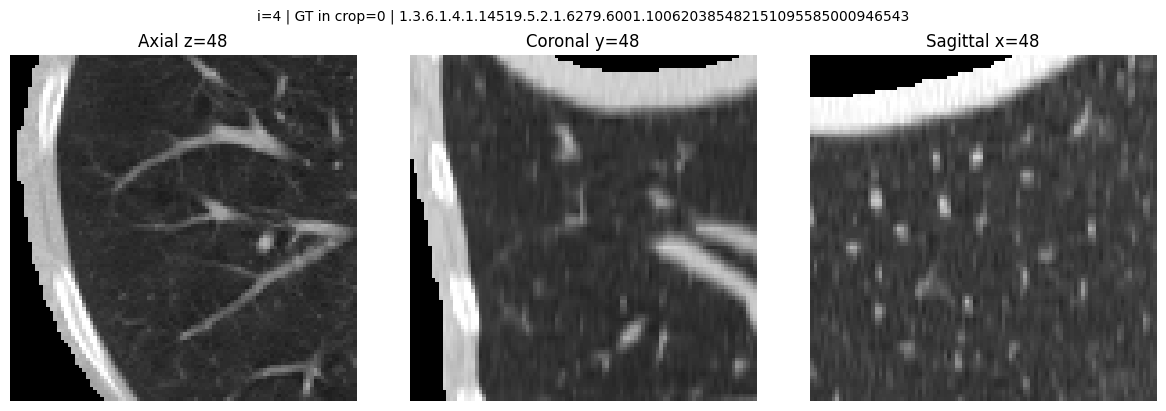

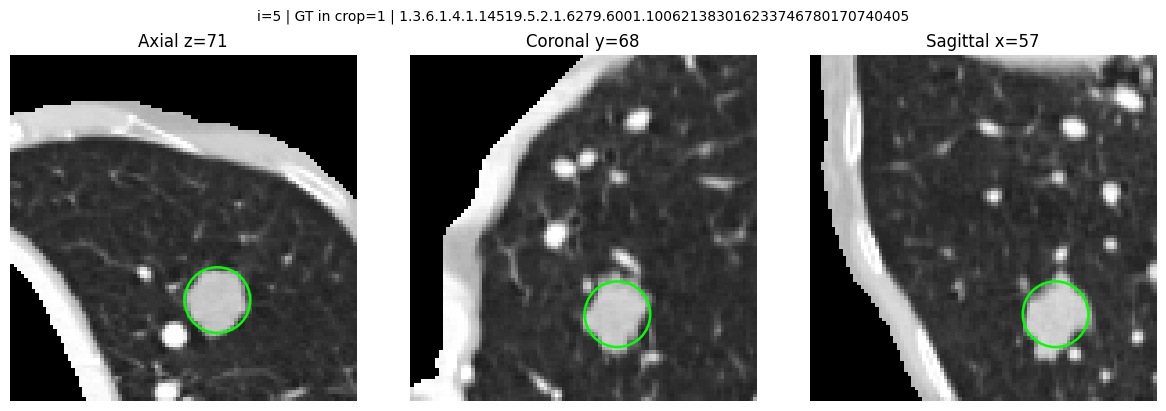

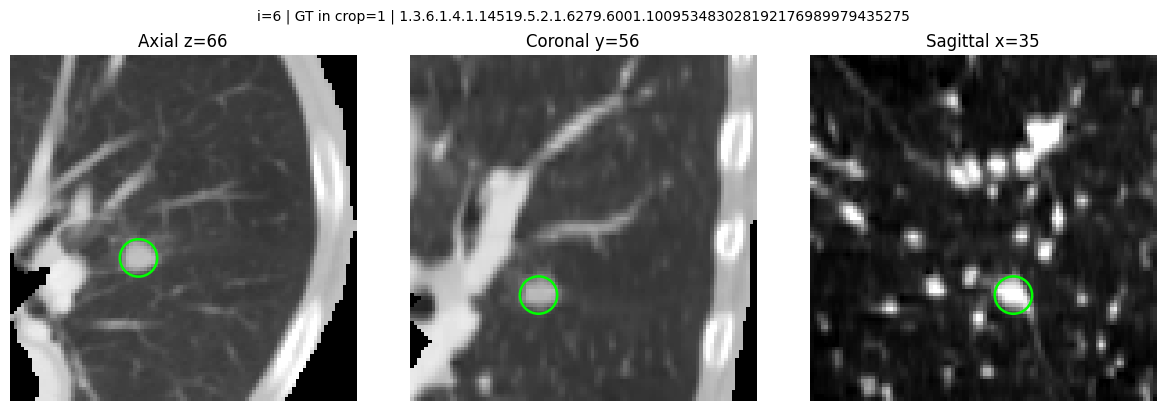

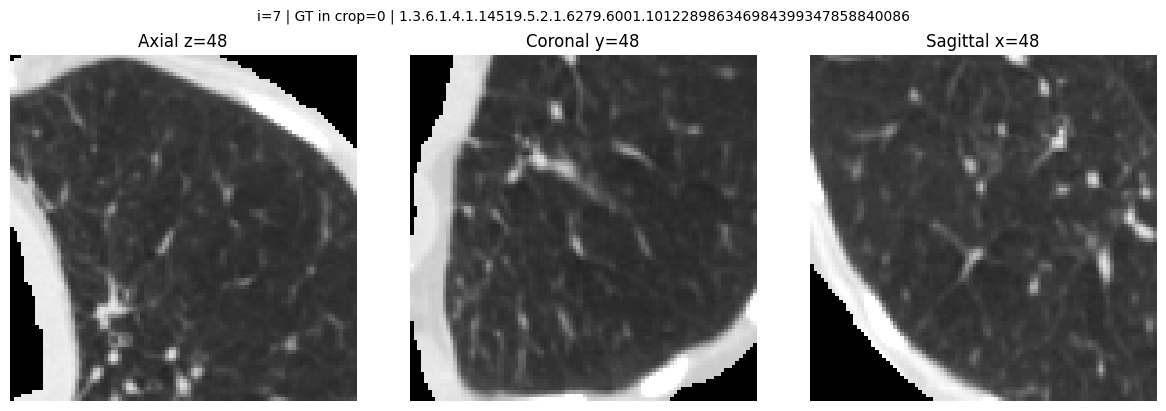

In [5]:
def display_image(arr):
    arr = np.asarray(arr, dtype=np.float32)
    lo, hi = np.percentile(arr, [1, 99])
    if hi <= lo:
        lo, hi = float(arr.min()), float(arr.max())
    return np.clip((arr - lo) / max(hi - lo, 1e-6), 0, 1)

def choose_slice(anns):
    if len(anns):
        center = anns[np.argmin(np.linalg.norm(anns[:, :3] - 48.0, axis=1)), :3]
        return [int(round(v)) for v in center]
    return [48, 48, 48]

def draw_axial_annots(ax, anns, z):
    for cz, cy, cx, r in anns:
        dz = abs(float(cz) - float(z))
        if dz <= float(r):
            rr = max((float(r) ** 2 - dz ** 2) ** 0.5, 1.5)
            ax.add_patch(Circle((float(cx), float(cy)), rr, fill=False, edgecolor='lime', linewidth=1.8))

def draw_coronal_annots(ax, anns, y):
    for cz, cy, cx, r in anns:
        dy = abs(float(cy) - float(y))
        if dy <= float(r):
            rr = max((float(r) ** 2 - dy ** 2) ** 0.5, 1.5)
            ax.add_patch(Circle((float(cx), float(cz)), rr, fill=False, edgecolor='lime', linewidth=1.8))

def draw_sagittal_annots(ax, anns, x):
    for cz, cy, cx, r in anns:
        dx = abs(float(cx) - float(x))
        if dx <= float(r):
            rr = max((float(r) ** 2 - dx ** 2) ** 0.5, 1.5)
            ax.add_patch(Circle((float(cy), float(cz)), rr, fill=False, edgecolor='lime', linewidth=1.8))

def show_sample(i):
    vol = images[i, 0].detach().cpu().numpy()
    anns = valid_annots(annots[i])
    z, y, x = choose_slice(anns)
    z = int(np.clip(z, 0, vol.shape[0] - 1))
    y = int(np.clip(y, 0, vol.shape[1] - 1))
    x = int(np.clip(x, 0, vol.shape[2] - 1))

    fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
    axes[0].imshow(display_image(vol[z]), cmap='gray')
    draw_axial_annots(axes[0], anns, z)
    axes[0].set_title(f'Axial z={z}')

    axes[1].imshow(display_image(vol[:, y, :]), cmap='gray')
    draw_coronal_annots(axes[1], anns, y)
    axes[1].set_title(f'Coronal y={y}')

    axes[2].imshow(display_image(vol[:, :, x]), cmap='gray')
    draw_sagittal_annots(axes[2], anns, x)
    axes[2].set_title(f'Sagittal x={x}')

    for ax in axes:
        ax.axis('off')
    fig.suptitle(f'i={i} | GT in crop={len(anns)} | {seriesuids[i]}', fontsize=10)
    plt.show()

for i in range(min(BATCH_SIZE, 8)):
    show_sample(i)

old HU min/max/mean/std: 0.4285714626312256 0.7928571701049805 0.5065352916717529 0.07597269117832184
new AUTO min/max/mean/std: -1.0 1.0 -0.5719631910324097 0.4171050190925598


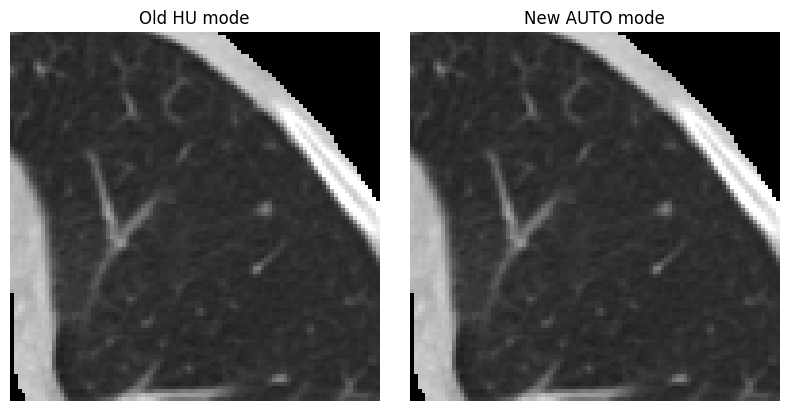

In [6]:
# Confronto opzionale: stesso sample con vecchia normalizzazione HU vs nuova AUTO.
old_ds = SCPMCSVVolumeDataset(
    csv_path=str(CSV_PATH),
    split=SPLIT,
    data_root=str(DATA_ROOT),
    crop_size=CROP_SIZE,
    samples_per_volume=1,
    clip=(-1000.0, 400.0),
    intensity_mode='hu',
    normalized_volume_cache_dir=None,
    positive_crop_prob=0.7,
    deterministic_seed=233,
)
old_x = old_ds[0]['image'].numpy()[0]
new_x = ds[0]['image'].numpy()[0]
print('old HU min/max/mean/std:', float(old_x.min()), float(old_x.max()), float(old_x.mean()), float(old_x.std()))
print('new AUTO min/max/mean/std:', float(new_x.min()), float(new_x.max()), float(new_x.mean()), float(new_x.std()))

fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
axes[0].imshow(display_image(old_x[48]), cmap='gray')
axes[0].set_title('Old HU mode')
axes[1].imshow(display_image(new_x[48]), cmap='gray')
axes[1].set_title('New AUTO mode')
for ax in axes:
    ax.axis('off')
plt.show()